# 중간보고용 간소 분석 노트북 (재현성 버전)

## 노트북 목적

중간보고용으로 아래 2가지를 간결하게 확인한다.

1. **H.264 IPB/GOP 특성 분석(핵심)**
2. **최소 전송효율 지표 비교(보조)**

## 데이터 경로와 역할

- `dataset/videos/`: 원본 공개 비디오(mp4) 저장 위치
- `dataset/traces/`: `extract_video_trace.py`로 생성한 **프레임 단위 분석 캐시 CSV**
  - 한번 생성된 trace는 재실행 시 재사용하여 속도/재현성을 높임
- `output/jupyter-notebook/assets/midreport/`: 중간보고용 CSV/PNG 산출물

## 핵심 지표 설명

- `late_frame_ratio`: 전체 프레임 중 deadline을 넘겨 도착한 프레임 비율
  - 값이 낮을수록 재생 지연 프레임이 적어 품질이 안정적
- `dropped_frame_ratio`: 정책에 의해 전송하지 않거나 실질적으로 유실 처리된 프레임 비율
- `useful_goodput_bytes`: deadline 내 도착해 실제 재생 기여가 가능한 바이트

## 정책 설명

- `heuristic_frame_aware`:
  - 고정 규칙 기반(IPB 타입, keyframe, deadline slack)으로 batch/flush를 결정
- `frame_action_adaptive`:
  - 프레임 중요도(score) + deadline slack + 네트워크 상태를 이용해
  - `RELIABLE_SINGLE`, `RELIABLE_MULTI`, `UNRELIABLE`, `DUPLICATE`, `DROP` 중 행동을 선택
  - 즉, 단순 규칙이 아니라 프레임별 전송 행동 매핑 기반 정책


In [26]:
# cell 1 : 환경 초기화 및 경로 설정
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().resolve()
for p in [REPO_ROOT, *REPO_ROOT.parents]:
    if (p / '.git').exists():
        REPO_ROOT = p
        break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tcp_batching_core import PolicyConfig, TransportConfig, VideoTraceConfig, run_simulation

VIDEO_DIR = REPO_ROOT / 'dataset' / 'videos'
TRACE_DIR = REPO_ROOT / 'dataset' / 'traces'
ASSET_DIR = REPO_ROOT / 'output' / 'jupyter-notebook' / 'assets' / 'midreport'

# True: 사용자가 dataset/videos에 넣은 수동 입력 비디오 중심 분석
# False: 노트북이 내려받은 공개 데이터셋 중심 분석(기본)
is_user_input_video_analyze = False

VIDEO_DIR.mkdir(parents=True, exist_ok=True)
TRACE_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
# Windows 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


def place_small_legend_right(ax, title: str | None = None) -> None:
    legend = ax.get_legend()
    if legend is None:
        return
    if title is not None:
        legend.set_title(title)
    legend.set_bbox_to_anchor((1.01, 1.0))
    try:
        legend.set_loc('upper left')
    except AttributeError:
        legend._loc = 2
    legend.get_frame().set_alpha(0.9)
    for txt in legend.get_texts():
        txt.set_fontsize(9)
    if legend.get_title() is not None:
        legend.get_title().set_fontsize(10)


def annotate_bar_values(ax, fmt: str = '{:.2f}', fontsize: int = 8) -> None:
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h):
            ax.annotate(
                fmt.format(h),
                (p.get_x() + p.get_width() / 2, h),
                ha='center',
                va='bottom',
                fontsize=fontsize,
                xytext=(0, 2),
                textcoords='offset points',
            )


print({
    'video_dir': str(VIDEO_DIR),
    'trace_dir': str(TRACE_DIR),
    'asset_dir': str(ASSET_DIR),
    'is_user_input_video_analyze': is_user_input_video_analyze,
})


{'video_dir': 'C:\\git\\network\\dataset\\videos', 'trace_dir': 'C:\\git\\network\\dataset\\traces', 'asset_dir': 'C:\\git\\network\\output\\jupyter-notebook\\assets\\midreport', 'is_user_input_video_analyze': False}


In [27]:
# cell 2 : 공개 데이터셋 다운로드 + 비디오 메타 구성
import shutil
import urllib.error
import urllib.request

PUBLIC_VIDEO_SOURCES = [
    # Google sample bucket (다양한 영상 특성)
    {'filename': 'bbb_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/BigBuckBunny.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'elephants_dream_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ElephantsDream.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'for_bigger_blazes_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerBlazes.mp4', 'group': 'nature', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'for_bigger_escape_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerEscapes.mp4', 'group': 'nature', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'for_bigger_fun_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerFun.mp4', 'group': 'sports', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'for_bigger_joyrides_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerJoyrides.mp4', 'group': 'sports', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'for_bigger_meltdowns_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerMeltdowns.mp4', 'group': 'sports', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'sintel_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/Sintel.mp4', 'group': 'animation', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'subaru_outback_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/SubaruOutbackOnStreetAndDirt.mp4', 'group': 'driving', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'tears_of_steel_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/TearsOfSteel.mp4', 'group': 'movie', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'we_are_going_on_bullrun_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/WeAreGoingOnBullrun.mp4', 'group': 'driving', 'motion_level': 'high', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'what_carre_can_be_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/WhatCarCanYouGetForAGrand.mp4', 'group': 'driving', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},

    # Blender / mediaelement / samplelib (해상도 혼합)
    {'filename': 'sintel_trailer_480p_blender.mp4', 'url': 'https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4', 'group': 'animation', 'motion_level': 'high', 'resolution': '480p', 'bitrate': 'medium'},
    {'filename': 'sintel_trailer_720p_blender.mp4', 'url': 'https://download.blender.org/durian/trailer/sintel_trailer-720p.mp4', 'group': 'animation', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'high'},
    {'filename': 'tos_trailer_480p_blender.mp4', 'url': 'https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4', 'group': 'movie', 'motion_level': 'medium', 'resolution': '480p', 'bitrate': 'medium'},
    {'filename': 'bbb_mediaelement.mp4', 'url': 'https://raw.githubusercontent.com/mediaelement/mediaelement-files/master/big_buck_bunny.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '360p', 'bitrate': 'low'},
    {'filename': 'echo_mediaelement.mp4', 'url': 'https://raw.githubusercontent.com/mediaelement/mediaelement-files/master/echo-hereweare.mp4', 'group': 'movie', 'motion_level': 'low', 'resolution': '360p', 'bitrate': 'low'},
    {'filename': 'sample_5s_360p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-5s.mp4', 'group': 'nature', 'motion_level': 'low', 'resolution': '360p', 'bitrate': 'low'},
    {'filename': 'sample_10s_720p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-10s.mp4', 'group': 'nature', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'sample_15s_720p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-15s.mp4', 'group': 'nature', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'sample_20s_1080p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-20s.mp4', 'group': 'nature', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'sample_30s_720p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-30s.mp4', 'group': 'nature', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': 'medium'},

    # Test-videos (해상도/비트레이트 표기형)
    {'filename': 'bbb_360p_1mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/360/Big_Buck_Bunny_360_10s_1MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '360p', 'bitrate': '1mbps'},
    {'filename': 'bbb_720p_1mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/720/Big_Buck_Bunny_720_10s_1MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': '1mbps'},
    {'filename': 'bbb_720p_2mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/720/Big_Buck_Bunny_720_10s_2MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': '2mbps'},
    {'filename': 'bbb_1080p_1mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/1080/Big_Buck_Bunny_1080_10s_1MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': '1mbps'},
    {'filename': 'bbb_1080p_5mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/1080/Big_Buck_Bunny_1080_10s_5MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': '5mbps'},
]


def download_if_missing(target: Path, url: str) -> tuple[bool, str]:
    if target.exists() and target.stat().st_size > 0:
        return True, 'cached'
    try:
        with urllib.request.urlopen(url, timeout=30) as response:
            with target.open('wb') as fout:
                shutil.copyfileobj(response, fout)
        return True, 'downloaded'
    except urllib.error.URLError as exc:
        return False, f'url_error: {exc}'
    except Exception as exc:  # noqa: BLE001
        return False, f'error: {exc}'


records = []
for item in PUBLIC_VIDEO_SOURCES:
    path = VIDEO_DIR / item['filename']
    ok, status = download_if_missing(path, item['url'])
    records.append({'file': item['filename'], 'status': status, 'ok': ok})

print('공개 데이터셋 다운로드 상태')
display(pd.DataFrame(records))

video_files = sorted(list(VIDEO_DIR.glob('*.mp4')) + list(VIDEO_DIR.glob('*.mkv')) + list(VIDEO_DIR.glob('*.mov')))

source_meta_map = {item['filename']: item for item in PUBLIC_VIDEO_SOURCES}
rows = []
for vp in video_files:
    stem = vp.stem
    src_meta = source_meta_map.get(vp.name)

    if src_meta is not None:
        group = src_meta.get('group', 'public')
        video_name = stem
        resolution = src_meta.get('resolution', 'na')
        bitrate = src_meta.get('bitrate', 'na')
        motion_level = src_meta.get('motion_level', 'medium')
        source_type = 'public'
    else:
        parts = stem.split('_')
        if len(parts) >= 4:
            group = parts[0]
            video_name = '_'.join(parts[1:])
            resolution = parts[-2]
            bitrate = parts[-1]
        else:
            group = 'manual'
            video_name = stem
            resolution = 'na'
            bitrate = 'na'
        motion_level = 'medium'
        source_type = 'manual'

    rows.append({
        'video_path': str(vp),
        'group': group,
        'video_name': video_name,
        'resolution': resolution,
        'bitrate': bitrate,
        'motion_level': motion_level,
        'source_type': source_type,
        'trace_csv': str((TRACE_DIR / f'{stem}_trace.csv')),
    })

video_meta_df = pd.DataFrame(rows)

if video_meta_df.empty:
    analysis_meta_df = video_meta_df.copy()
else:
    manual_meta_df = video_meta_df[video_meta_df['source_type'] == 'manual'].copy()
    public_meta_df = video_meta_df[video_meta_df['source_type'] == 'public'].copy()

    if is_user_input_video_analyze:
        # 사용자 입력 분석 모드에서는 manual 우선
        analysis_meta_df = manual_meta_df if not manual_meta_df.empty else video_meta_df.copy()
        selected_mode_text = 'manual(사용자 입력)'
    else:
        # 기본은 공개 데이터셋 분석
        analysis_meta_df = public_meta_df if not public_meta_df.empty else video_meta_df.copy()
        selected_mode_text = 'public(공개 데이터셋)'

print('전체 비디오 메타')
display(video_meta_df)
if not video_meta_df.empty:
    print(f'분석 모드: {selected_mode_text}')
print('분석 대상 비디오 메타')
display(analysis_meta_df)
print(f'전체 비디오 개수: {len(video_meta_df)} / 분석 대상 개수: {len(analysis_meta_df)}')
if len(video_meta_df) == 0:
    print('다운로드 실패 또는 입력 비디오 없음. dataset/videos에 mp4를 수동 추가 후 재실행하세요.')


공개 데이터셋 다운로드 상태


,file,status,ok
0,bbb_google.mp4,url_error: HTTP Error 403: Forbidden,False
1,elephants_dream_google.mp4,url_error: HTTP Error 403: Forbidden,False
2,for_bigger_blazes_google.mp4,url_error: HTTP Error 403: Forbidden,False
3,for_bigger_escape_google.mp4,url_error: HTTP Error 403: Forbidden,False
4,for_bigger_fun_google.mp4,url_error: HTTP Error 403: Forbidden,False
5,for_bigger_joyrides_google.mp4,url_error: HTTP Error 403: Forbidden,False
6,for_bigger_meltdowns_google.mp4,url_error: HTTP Error 403: Forbidden,False
7,sintel_google.mp4,url_error: HTTP Error 403: Forbidden,False
8,subaru_outback_google.mp4,url_error: HTTP Error 403: Forbidden,False
9,tears_of_steel_google.mp4,url_error: HTTP Error 403: Forbidden,False


전체 비디오 메타


,video_path,group,video_name,resolution,bitrate,motion_level,source_type,trace_csv
0,C:\git\network\dataset\videos\237639_tiny.mp4,manual,237639_tiny,na,na,medium,manual,C:\git\network\dataset\traces\237639_tiny_trac...
1,C:\git\network\dataset\videos\248286_tiny.mp4,manual,248286_tiny,na,na,medium,manual,C:\git\network\dataset\traces\248286_tiny_trac...
2,C:\git\network\dataset\videos\248288_tiny.mp4,manual,248288_tiny,na,na,medium,manual,C:\git\network\dataset\traces\248288_tiny_trac...
3,C:\git\network\dataset\videos\253980_tiny.mp4,manual,253980_tiny,na,na,medium,manual,C:\git\network\dataset\traces\253980_tiny_trac...
4,C:\git\network\dataset\videos\254006_tiny.mp4,manual,254006_tiny,na,na,medium,manual,C:\git\network\dataset\traces\254006_tiny_trac...
5,C:\git\network\dataset\videos\290291_tiny.mp4,manual,290291_tiny,na,na,medium,manual,C:\git\network\dataset\traces\290291_tiny_trac...
6,C:\git\network\dataset\videos\297855_tiny.mp4,manual,297855_tiny,na,na,medium,manual,C:\git\network\dataset\traces\297855_tiny_trac...
7,C:\git\network\dataset\videos\311102_tiny.mp4,manual,311102_tiny,na,na,medium,manual,C:\git\network\dataset\traces\311102_tiny_trac...
8,C:\git\network\dataset\videos\animation_bbb_36...,animation,bbb_360p_1mbps,360p,1mbps,medium,manual,C:\git\network\dataset\traces\animation_bbb_36...
9,C:\git\network\dataset\videos\animation_echo_3...,animation,echo_360p_1mbps,360p,1mbps,medium,manual,C:\git\network\dataset\traces\animation_echo_3...


분석 모드: public(공개 데이터셋)
분석 대상 비디오 메타


,video_path,group,video_name,resolution,bitrate,motion_level,source_type,trace_csv
10,C:\git\network\dataset\videos\bbb_mediaelement...,animation,bbb_mediaelement,360p,low,medium,public,C:\git\network\dataset\traces\bbb_mediaelement...
11,C:\git\network\dataset\videos\echo_mediaelemen...,movie,echo_mediaelement,360p,low,low,public,C:\git\network\dataset\traces\echo_mediaelemen...
13,C:\git\network\dataset\videos\sample_10s_720p.mp4,nature,sample_10s_720p,720p,medium,medium,public,C:\git\network\dataset\traces\sample_10s_720p_...
14,C:\git\network\dataset\videos\sample_15s_720p.mp4,nature,sample_15s_720p,720p,medium,medium,public,C:\git\network\dataset\traces\sample_15s_720p_...
15,C:\git\network\dataset\videos\sample_20s_1080p...,nature,sample_20s_1080p,1080p,high,medium,public,C:\git\network\dataset\traces\sample_20s_1080p...
16,C:\git\network\dataset\videos\sample_30s_720p.mp4,nature,sample_30s_720p,720p,medium,medium,public,C:\git\network\dataset\traces\sample_30s_720p_...
17,C:\git\network\dataset\videos\sample_5s_360p.mp4,nature,sample_5s_360p,360p,low,low,public,C:\git\network\dataset\traces\sample_5s_360p_t...


전체 비디오 개수: 18 / 분석 대상 개수: 7


In [28]:
# cell 3 : frame trace 자동 생성(없을 때만)
def ensure_trace(video_path: Path, trace_path: Path, playback_buffer_ms: float = 50.0) -> None:
    if trace_path.exists():
        return
    cmd = [
        sys.executable,
        str(REPO_ROOT / 'scripts' / 'extract_video_trace.py'),
        '--input', str(video_path),
        '--output', str(trace_path),
        '--playback-buffer-ms', str(playback_buffer_ms),
    ]
    subprocess.run(cmd, check=True)

for row in analysis_meta_df.itertuples(index=False):
    ensure_trace(Path(row.video_path), Path(row.trace_csv))

print('trace 생성/확인 완료')


trace 생성/확인 완료


,group,video_name,frame_count,i_count,p_count,b_count,i_ratio,p_ratio,b_ratio,i_per_1000_frames,median_gop_len_frames,mean_payload_bytes
0,animation,bbb_mediaelement,1440,23,1417,0,0.015972,0.984028,0.000000,15.972222,64.0,3193.472917
1,movie,echo_mediaelement,1338,14,1324,0,0.010463,0.989537,0.000000,10.463378,120.0,3408.633034
2,nature,sample_10s_720p,303,2,76,225,0.006601,0.250825,0.742574,6.600660,250.0,17549.273927
3,nature,sample_15s_720p,464,2,117,345,0.004310,0.252155,0.743534,4.310345,250.0,25113.081897
4,nature,sample_20s_1080p,605,3,152,450,0.004959,0.251240,0.743802,4.958678,250.0,18963.310744
5,nature,sample_30s_720p,911,4,229,678,0.004391,0.251372,0.744237,4.390779,250.0,23207.020856
6,nature,sample_5s_360p,171,1,43,127,0.005848,0.251462,0.742690,5.847953,171.0,16072.508772


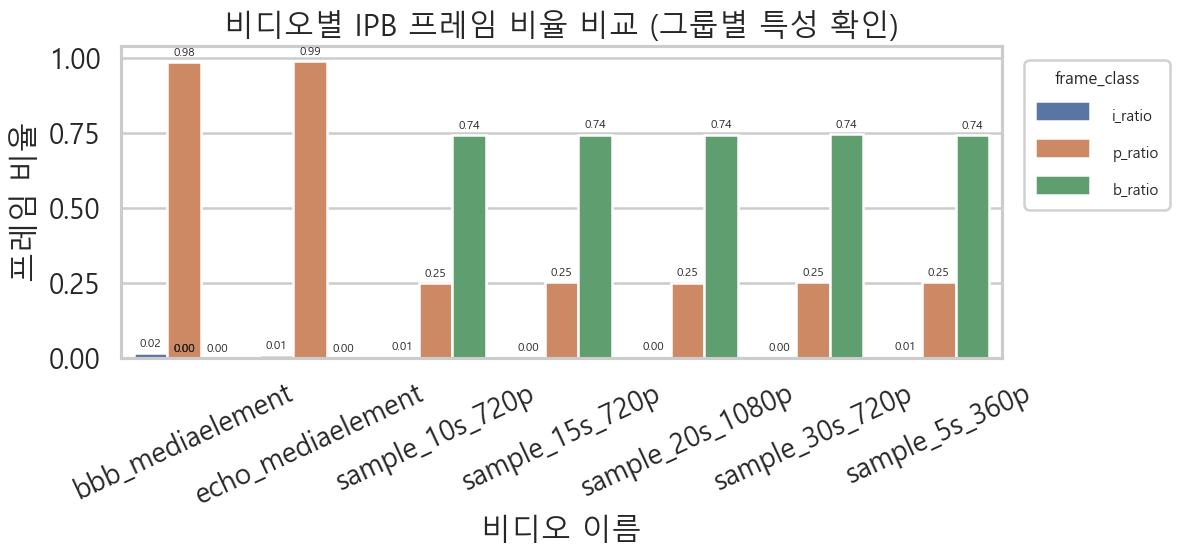

[도출식][IPB 막대값 = frame_class_count / frame_count]


,video_name,frame_class,count,frame_count,bar_value,formula
0,bbb_mediaelement,i_ratio,23,1440,0.015972,23/1440=0.015972
1,bbb_mediaelement,p_ratio,1417,1440,0.984028,1417/1440=0.984028
2,bbb_mediaelement,b_ratio,0,1440,0.000000,0/1440=0.000000
3,echo_mediaelement,i_ratio,14,1338,0.010463,14/1338=0.010463
4,echo_mediaelement,p_ratio,1324,1338,0.989537,1324/1338=0.989537
5,echo_mediaelement,b_ratio,0,1338,0.000000,0/1338=0.000000
6,sample_10s_720p,i_ratio,2,303,0.006601,2/303=0.006601
7,sample_10s_720p,p_ratio,76,303,0.250825,76/303=0.250825
8,sample_10s_720p,b_ratio,225,303,0.742574,225/303=0.742574
9,sample_15s_720p,i_ratio,2,464,0.004310,2/464=0.004310


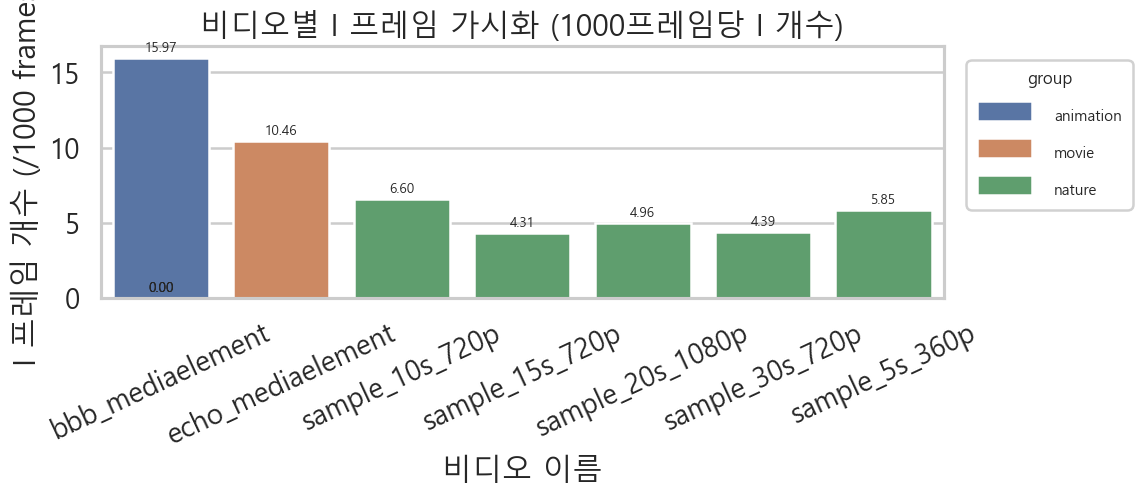

[도출식][I 가시화 막대값 = (i_count / frame_count) * 1000]


,video_name,i_count,frame_count,i_per_1000_frames,formula
0,bbb_mediaelement,23,1440,15.972222,(23/1440)*1000=15.972222
1,echo_mediaelement,14,1338,10.463378,(14/1338)*1000=10.463378
2,sample_10s_720p,2,303,6.600660,(2/303)*1000=6.600660
3,sample_15s_720p,2,464,4.310345,(2/464)*1000=4.310345
4,sample_20s_1080p,3,605,4.958678,(3/605)*1000=4.958678
5,sample_30s_720p,4,911,4.390779,(4/911)*1000=4.390779
6,sample_5s_360p,1,171,5.847953,(1/171)*1000=5.847953


In [29]:
# cell 4 : IPB/GOP 특성 요약(핵심)
ipb_rows = []
for row in analysis_meta_df.itertuples(index=False):
    trace_df = pd.read_csv(row.trace_csv)
    frame_count = len(trace_df)
    if frame_count == 0:
        continue
    i_count = int((trace_df['frame_type'].str.upper() == 'I').sum())
    p_count = int((trace_df['frame_type'].str.upper() == 'P').sum())
    b_count = int((trace_df['frame_type'].str.upper() == 'B').sum())
    i_ratio = float(i_count / frame_count)
    p_ratio = float(p_count / frame_count)
    b_ratio = float(b_count / frame_count)
    key_idx = trace_df.index[trace_df['key_frame'] == 1].to_numpy()
    gop_len = float(np.median(np.diff(key_idx))) if len(key_idx) >= 2 else float(frame_count)
    ipb_rows.append({
        'group': row.group,
        'video_name': row.video_name,
        'frame_count': frame_count,
        'i_count': i_count,
        'p_count': p_count,
        'b_count': b_count,
        'i_ratio': i_ratio,
        'p_ratio': p_ratio,
        'b_ratio': b_ratio,
        'i_per_1000_frames': float(i_ratio * 1000.0),
        'median_gop_len_frames': gop_len,
        'mean_payload_bytes': float(trace_df['payload_bytes'].mean()),
    })

ipb_summary_df = pd.DataFrame(ipb_rows)
if ipb_summary_df.empty:
    print('IPB 요약 대상이 없습니다. dataset/videos에 비디오 파일을 추가한 뒤 다시 실행하세요.')
else:
    ipb_summary_df = ipb_summary_df.sort_values(['group', 'video_name'])
    display(ipb_summary_df)
    ipb_summary_df.to_csv(ASSET_DIR / 'midreport_ipb_summary.csv', index=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    plot_df = ipb_summary_df.melt(id_vars=['group', 'video_name'], value_vars=['i_ratio', 'p_ratio', 'b_ratio'], var_name='frame_class', value_name='ratio')
    sns.barplot(data=plot_df, x='video_name', y='ratio', hue='frame_class', ax=ax)
    ax.set_title('비디오별 IPB 프레임 비율 비교 (그룹별 특성 확인)')
    ax.set_xlabel('비디오 이름')
    ax.set_ylabel('프레임 비율')
    ax.tick_params(axis='x', rotation=25)
    place_small_legend_right(ax, title='frame_class')
    annotate_bar_values(ax, fmt='{:.2f}', fontsize=7)
    fig.tight_layout(rect=[0.0, 0.0, 0.84, 1.0])
    fig.savefig(ASSET_DIR / 'midreport_ipb_ratio.png')
    plt.show()

    ipb_explain_rows = []
    for r in ipb_summary_df.itertuples(index=False):
        for frame_class, count_col, ratio_col in [
            ('i_ratio', 'i_count', 'i_ratio'),
            ('p_ratio', 'p_count', 'p_ratio'),
            ('b_ratio', 'b_count', 'b_ratio'),
        ]:
            count = int(getattr(r, count_col))
            total = int(r.frame_count)
            value = float(getattr(r, ratio_col))
            ipb_explain_rows.append({
                'video_name': r.video_name,
                'frame_class': frame_class,
                'count': count,
                'frame_count': total,
                'bar_value': value,
                'formula': f'{count}/{total}={value:.6f}',
            })
    ipb_explain_df = pd.DataFrame(ipb_explain_rows)
    print('[도출식][IPB 막대값 = frame_class_count / frame_count]')
    display(ipb_explain_df)

    # I 프레임 가시성 보강: 비율(%) + 1000프레임당 I 개수 동시 확인
    i_focus_df = ipb_summary_df[['group', 'video_name', 'i_ratio', 'i_per_1000_frames', 'i_count', 'frame_count']].copy()
    i_focus_df['i_ratio_pct'] = i_focus_df['i_ratio'] * 100.0

    fig_i, ax_i = plt.subplots(figsize=(12, 4.5))
    sns.barplot(data=i_focus_df, x='video_name', y='i_per_1000_frames', hue='group', dodge=False, ax=ax_i)
    ax_i.set_title('비디오별 I 프레임 가시화 (1000프레임당 I 개수)')
    ax_i.set_xlabel('비디오 이름')
    ax_i.set_ylabel('I 프레임 개수 (/1000 frames)')
    ax_i.tick_params(axis='x', rotation=25)
    place_small_legend_right(ax_i, title='group')

    annotate_bar_values(ax_i, fmt='{:.2f}', fontsize=8)

    fig_i.tight_layout(rect=[0.0, 0.0, 0.84, 1.0])
    fig_i.savefig(ASSET_DIR / 'midreport_i_ratio_focus.png')
    plt.show()

    i_focus_explain_df = i_focus_df[['video_name', 'i_count', 'frame_count', 'i_per_1000_frames']].copy()
    i_focus_explain_df['formula'] = i_focus_explain_df.apply(
        lambda x: f"({int(x['i_count'])}/{int(x['frame_count'])})*1000={x['i_per_1000_frames']:.6f}",
        axis=1,
    )
    print('[도출식][I 가시화 막대값 = (i_count / frame_count) * 1000]')
    display(i_focus_explain_df)


,group,video_name,policy,late_frame_ratio,dropped_frame_ratio,useful_goodput_bytes,decodable_gop_ratio
1,animation,bbb_mediaelement,frame_action_adaptive,0.000694,0.000000,4526274.0,0.956522
0,animation,bbb_mediaelement,heuristic_frame_aware,0.000694,0.000000,4526274.0,0.956522
3,movie,echo_mediaelement,frame_action_adaptive,0.000000,0.000000,4560751.0,1.000000
2,movie,echo_mediaelement,heuristic_frame_aware,0.000000,0.000000,4560751.0,1.000000
5,nature,sample_10s_720p,frame_action_adaptive,0.270627,0.095710,2155679.0,0.000000
4,nature,sample_10s_720p,heuristic_frame_aware,0.861386,0.000000,369828.0,0.000000
7,nature,sample_15s_720p,frame_action_adaptive,0.887931,0.545259,299616.0,0.000000
6,nature,sample_15s_720p,heuristic_frame_aware,1.000000,0.000000,0.0,0.000000
9,nature,sample_20s_1080p,frame_action_adaptive,0.447934,0.181818,2996932.0,0.000000
8,nature,sample_20s_1080p,heuristic_frame_aware,0.776860,0.000000,1446434.0,0.000000


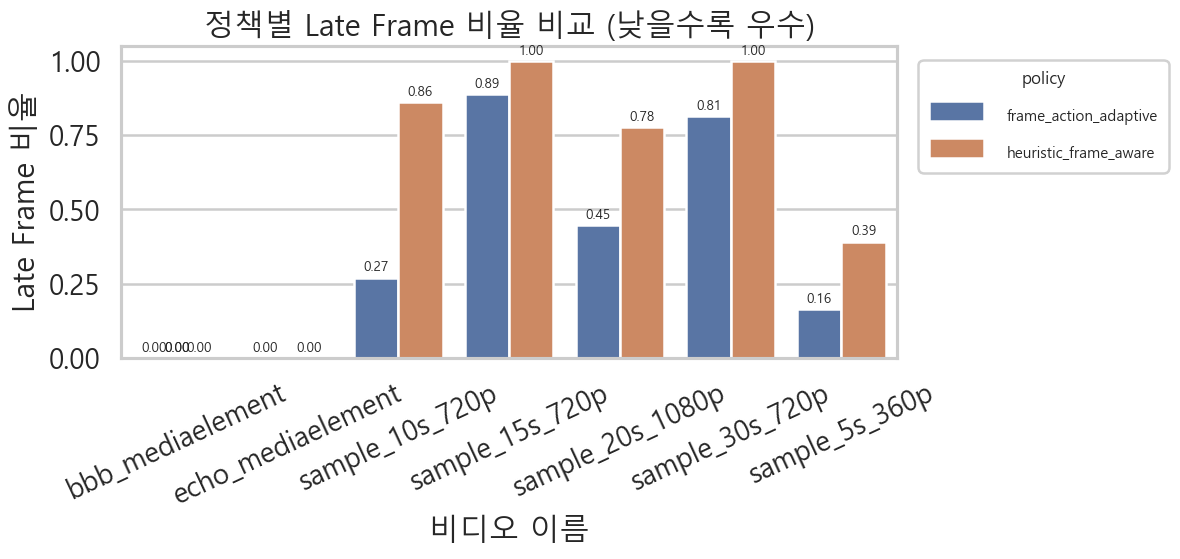

[도출식][Late Frame 막대값 = late_frame_ratio (추정 late_frames = late_frame_ratio * frame_count)]


,group,video_name,policy,late_frame_ratio,frame_count,estimated_late_frames,formula
1,animation,bbb_mediaelement,frame_action_adaptive,0.000694,1440,1,1/1440=0.000694
0,animation,bbb_mediaelement,heuristic_frame_aware,0.000694,1440,1,1/1440=0.000694
3,movie,echo_mediaelement,frame_action_adaptive,0.000000,1338,0,0/1338=0.000000
2,movie,echo_mediaelement,heuristic_frame_aware,0.000000,1338,0,0/1338=0.000000
5,nature,sample_10s_720p,frame_action_adaptive,0.270627,303,82,82/303=0.270627
4,nature,sample_10s_720p,heuristic_frame_aware,0.861386,303,261,261/303=0.861386
7,nature,sample_15s_720p,frame_action_adaptive,0.887931,464,412,412/464=0.887931
6,nature,sample_15s_720p,heuristic_frame_aware,1.000000,464,464,464/464=1.000000
9,nature,sample_20s_1080p,frame_action_adaptive,0.447934,605,271,271/605=0.447934
8,nature,sample_20s_1080p,heuristic_frame_aware,0.776860,605,470,470/605=0.776860


In [30]:
# cell 5 : 최소 전송효율 지표 비교(보조)
transport = TransportConfig(rtt_ms=10, bandwidth_mbps=5, delayed_ack_ms=40)
policies = [
    PolicyConfig('heuristic_frame_aware'),
    PolicyConfig('frame_action_adaptive', available_paths=2),
]

eff_rows = []
for row in analysis_meta_df.itertuples(index=False):
    workload = VideoTraceConfig(trace_csv_path=Path(row.trace_csv), playback_buffer_ms=50.0, loop_count=1)
    for policy in policies:
        result = run_simulation(workload, transport, policy)
        eff_rows.append({
            'group': row.group,
            'video_name': row.video_name,
            'policy': policy.name,
            'late_frame_ratio': result['late_frame_ratio'],
            'dropped_frame_ratio': result['dropped_frame_ratio'],
            'useful_goodput_bytes': result['useful_goodput_bytes'],
            'decodable_gop_ratio': result['decodable_gop_ratio'],
        })

eff_summary_df = pd.DataFrame(eff_rows)
if eff_summary_df.empty:
    print('전송효율 비교 대상이 없습니다. dataset/videos에 비디오 파일을 추가한 뒤 다시 실행하세요.')
else:
    eff_summary_df = eff_summary_df.sort_values(['group', 'video_name', 'policy'])
    display(eff_summary_df)
    eff_summary_df.to_csv(ASSET_DIR / 'midreport_transport_efficiency.csv', index=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=eff_summary_df, x='video_name', y='late_frame_ratio', hue='policy', ax=ax)
    ax.set_title('정책별 Late Frame 비율 비교 (낮을수록 우수)')
    ax.set_xlabel('비디오 이름')
    ax.set_ylabel('Late Frame 비율')
    ax.tick_params(axis='x', rotation=25)
    place_small_legend_right(ax, title='policy')
    annotate_bar_values(ax, fmt='{:.2f}', fontsize=8)
    fig.tight_layout(rect=[0.0, 0.0, 0.84, 1.0])
    fig.savefig(ASSET_DIR / 'midreport_late_frame_ratio.png')
    plt.show()

    frame_count_map = ipb_summary_df.set_index('video_name')['frame_count'].to_dict() if 'ipb_summary_df' in globals() else {}
    eff_explain_df = eff_summary_df.copy()
    eff_explain_df['frame_count'] = eff_explain_df['video_name'].map(frame_count_map)
    eff_explain_df['estimated_late_frames'] = eff_explain_df.apply(
        lambda x: int(round(x['late_frame_ratio'] * x['frame_count'])) if pd.notna(x['frame_count']) else np.nan,
        axis=1,
    )
    eff_explain_df['formula'] = eff_explain_df.apply(
        lambda x: (
            f"{int(x['estimated_late_frames'])}/{int(x['frame_count'])}={x['late_frame_ratio']:.6f}"
            if pd.notna(x['frame_count']) and pd.notna(x['estimated_late_frames'])
            else f"ratio_only={x['late_frame_ratio']:.6f}"
        ),
        axis=1,
    )
    print('[도출식][Late Frame 막대값 = late_frame_ratio (추정 late_frames = late_frame_ratio * frame_count)]')
    display(eff_explain_df[['group', 'video_name', 'policy', 'late_frame_ratio', 'frame_count', 'estimated_late_frames', 'formula']])


## 중간보고 작성 체크리스트

- `midreport_ipb_summary.csv`에서 그룹별 IPB/GOP 특성 차이 정리
- `midreport_transport_efficiency.csv`에서 정책별 late/drop/goodput 비교 정리
- 해석은 "IPB 특성이 전송 행동에 주는 영향" 중심으로 3~5줄 요약
